#  Data Understanding & EDA
Here we'll understand target, its drivers, and data.
I will not modifiy data here, 
every finding will have a decision in the cleaning, feature, and  modelling stages.

## 1. Imports

In [4]:
import pandas as pd
import plotly.express as px

from regression_intelligence.analysis import eda
from regression_intelligence.data.ingestion import ingest

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Load

In [6]:
df = ingest()
print(df.shape)
print()
print(df.head())

2026-10-05 13:24:51,240 | INFO     | regression_intelligence.data.ingestion | Loaded 1017209 rows x 18 columns
(1017209, 18)

   store  day_of_week       date  sales  customers  open  promo state_holiday  \
0      1            2 2013-01-01      0          0     0      0             a   
1      2            2 2013-01-01      0          0     0      0             a   
2      3            2 2013-01-01      0          0     0      0             a   
3      4            2 2013-01-01      0          0     0      0             a   
4      5            2 2013-01-01      0          0     0      0             a   

   school_holiday store_type assortment  competition_distance  \
0               1          c          a              1,270.00   
1               1          a          a                570.00   
2               1          a          a             14,130.00   
3               1          c          c                620.00   
4               1          a          a             29,910.00 

## 3. Structure & Missing values

In [8]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   store                         1017209 non-null  int64         
 1   day_of_week                   1017209 non-null  int64         
 2   date                          1017209 non-null  datetime64[us]
 3   sales                         1017209 non-null  int64         
 4   customers                     1017209 non-null  int64         
 5   open                          1017209 non-null  int64         
 6   promo                         1017209 non-null  int64         
 7   state_holiday                 1017209 non-null  str           
 8   school_holiday                1017209 non-null  int64         
 9   store_type                    1017209 non-null  str           
 10  assortment                    1017209 non-null  str           
 11  competiti

In [9]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
store,"1,017,209.00",558.43,1.00,280.00,558.00,838.00,"1,115.00",321.91
day_of_week,"1,017,209.00",4.00,1.00,2.00,4.00,6.00,7.00,2.00
date,1017209,2014-04-11 01:30:42.846061,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
sales,"1,017,209.00","5,773.82",0.00,"3,727.00","5,744.00","7,856.00","41,551.00","3,849.93"
customers,"1,017,209.00",633.15,0.00,405.00,609.00,837.00,"7,388.00",464.41
open,"1,017,209.00",0.83,0.00,1.00,1.00,1.00,1.00,0.38
promo,"1,017,209.00",0.38,0.00,0.00,0.00,1.00,1.00,0.49
school_holiday,"1,017,209.00",0.18,0.00,0.00,0.00,0.00,1.00,0.38
competition_distance,"1,014,567.00","5,430.09",20.00,710.00,"2,330.00","6,890.00","75,860.00","7,715.32"
competition_open_since_month,"693,861.00",7.22,1.00,4.00,8.00,10.00,12.00,3.21


In [10]:
display(eda.missing_summary(df))

,missing,pct
promo2_since_year,508031,49.94
promo2_since_week,508031,49.94
promo_interval,508031,49.94
competition_open_since_month,323348,31.79
competition_open_since_year,323348,31.79
competition_distance,2642,0.26


In [11]:
pd.crosstab(
    df["promo2"],
    df["promo2_since_year"].isna(),
    rownames=["promo2"],
    colnames=["since_year_missing"],
)

since_year_missing,False,True
promo2,,
0,0,508031
1,509178,0


## 4. Closed days & EDA Frame

In [13]:
print(df["open"].value_counts(normalize=True).round(3))
print()
print(df.loc[df["open"] == 0, "sales"].describe())

open
1   0.83
0   0.17
Name: proportion, dtype: float64

count   172,817.00
mean          0.00
std           0.00
min           0.00
25%           0.00
50%           0.00
75%           0.00
max           0.00
Name: sales, dtype: float64


In [14]:
eda_df = eda.open_days(df).assign(
    month=lambda d: d["date"].dt.month, year=lambda d: d["date"].dt.year
)
print(f"{len(eda_df):,} of {len(df):,} rows kept (stores that actually traded)")

844,338 of 1,017,209 rows kept (stores that actually traded)


## 5. Target

In [15]:
display(eda.target_skew(eda_df["sales"]))

skew_raw      1.59
skew_log1p   -0.11
dtype: float64

WindowsPath('C:/Users/PMYLS/Desktop/regression-intelligence-system/reports/figures/01_target_distribution.png')

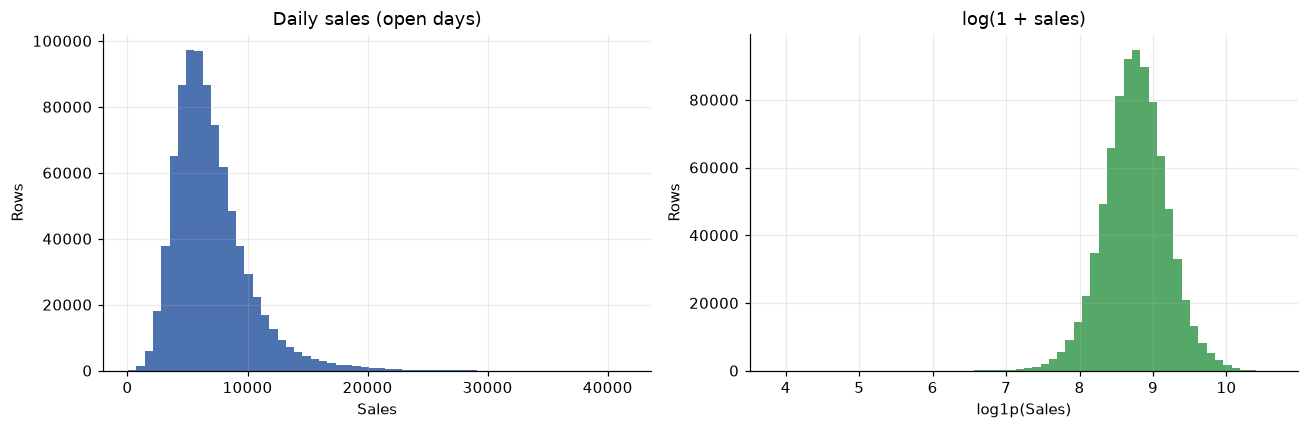

In [16]:
fig = eda.plot_target_distribution(eda_df)
eda.save_fig(fig, "01_target_distribution")

## 6. Time patterns

WindowsPath('C:/Users/PMYLS/Desktop/regression-intelligence-system/reports/figures/02_time_patterns.png')

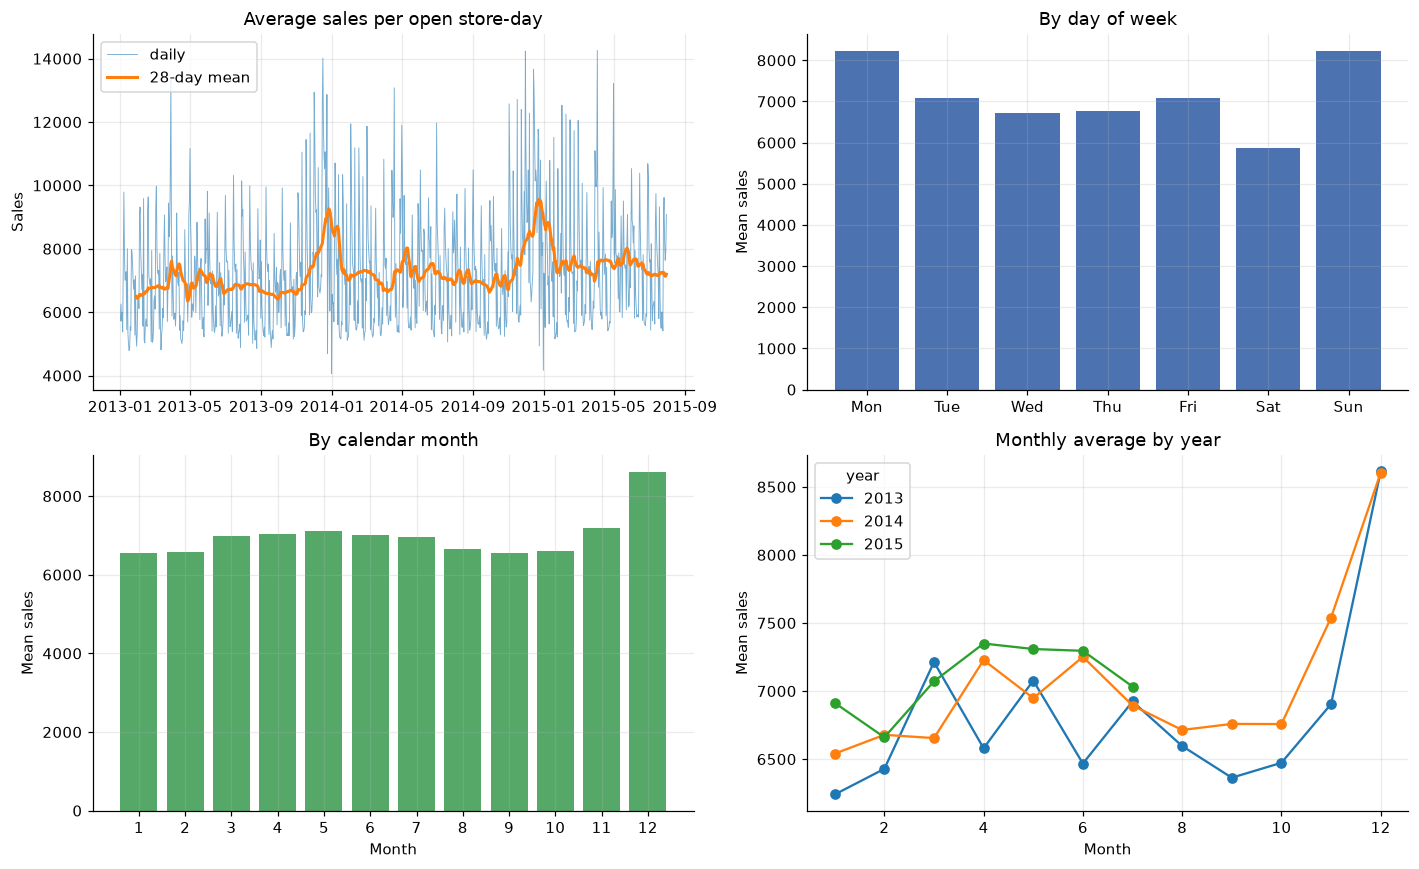

In [17]:
fig = eda.plot_time_patterns(eda_df)
eda.save_fig(fig, "02_time_patterns")

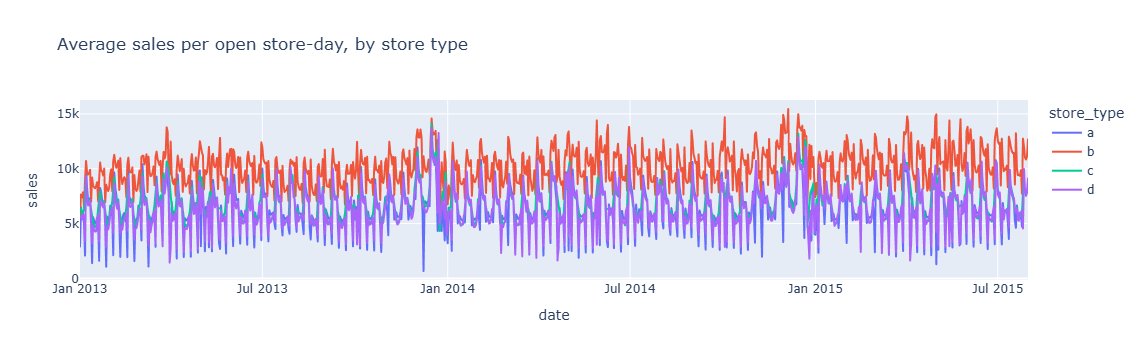

In [18]:
daily = eda_df.groupby(["date", "store_type"], as_index=False)["sales"].mean()
px.line(
    daily,
    x="date",
    y="sales",
    color="store_type",
    title="Average sales per open store-day, by store type",
).show()

## 7. driver(promo, holidays, store, type, assortment)

WindowsPath('C:/Users/PMYLS/Desktop/regression-intelligence-system/reports/figures/03_categorical_effects.png')

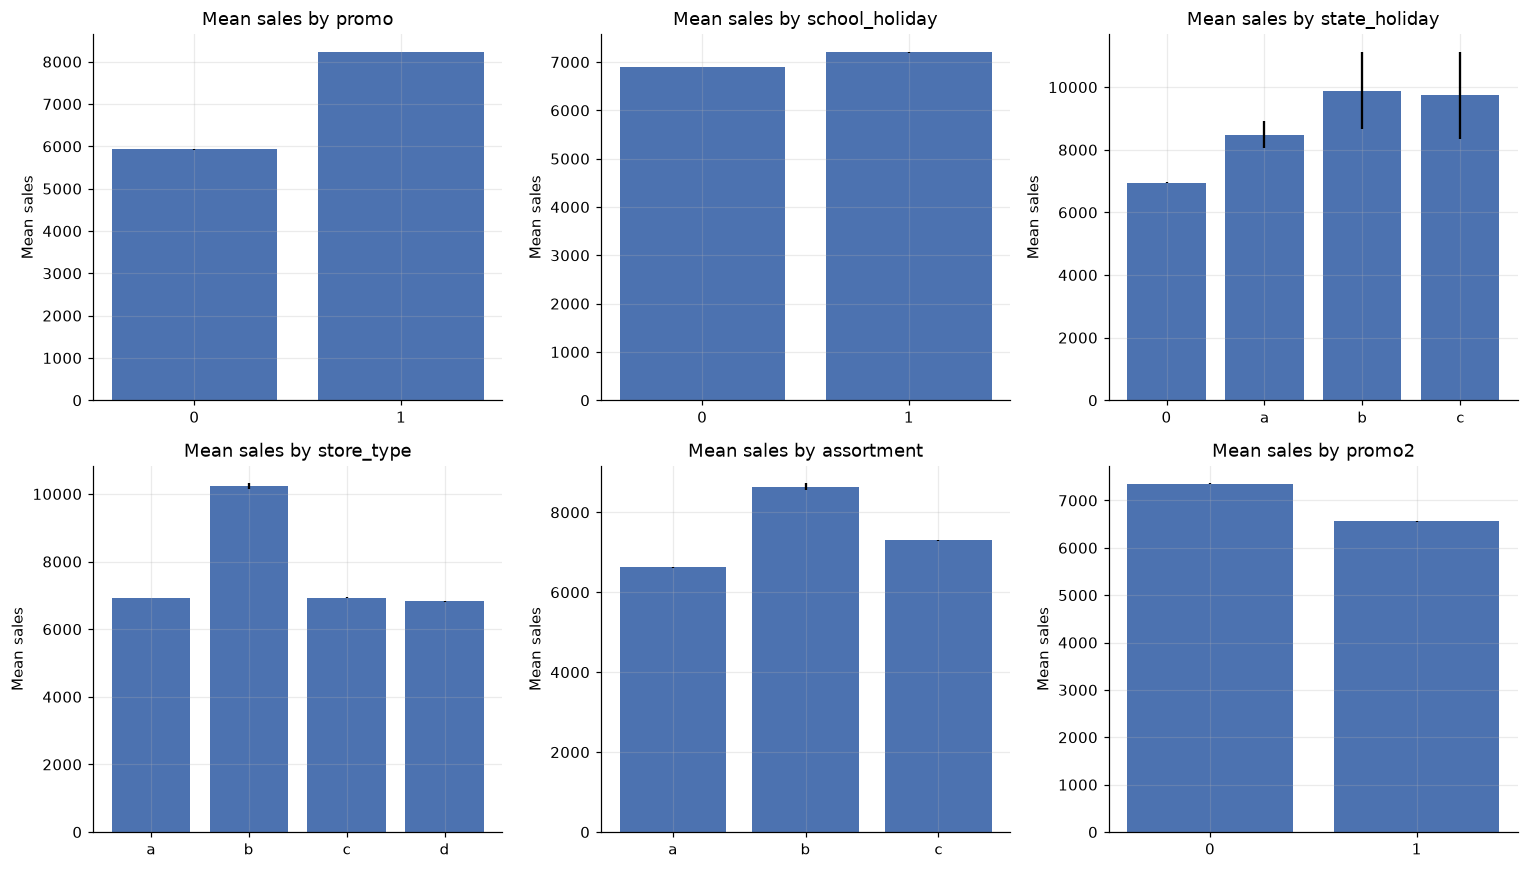

In [19]:
fig = eda.plot_categorical_effects(eda_df)
eda.save_fig(fig, "03_categorical_effects")

In [20]:
means = eda_df.groupby("promo")["sales"].agg(["mean", "median", "count"])
display(means)
print(f"Promo lift in mean sales: {means.loc[1, 'mean'] / means.loc[0, 'mean'] - 1:.1%}")

,mean,median,count
promo,,,
0,"5,929.83","5,459.00",467463
1,"8,228.74","7,650.00",376875


Promo lift in mean sales: 38.8%


## 8. competition and store differences

WindowsPath('C:/Users/PMYLS/Desktop/regression-intelligence-system/reports/figures/04_competition_distance.png')

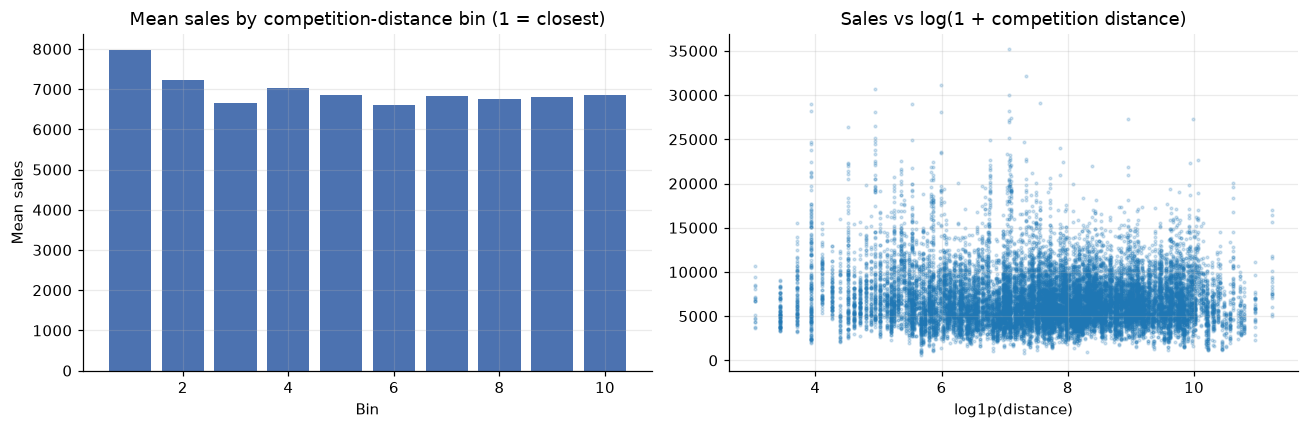

In [21]:
fig = eda.plot_competition_distance(eda_df)
eda.save_fig(fig, "04_competition_distance")

WindowsPath('C:/Users/PMYLS/Desktop/regression-intelligence-system/reports/figures/05_store_heterogeneity.png')

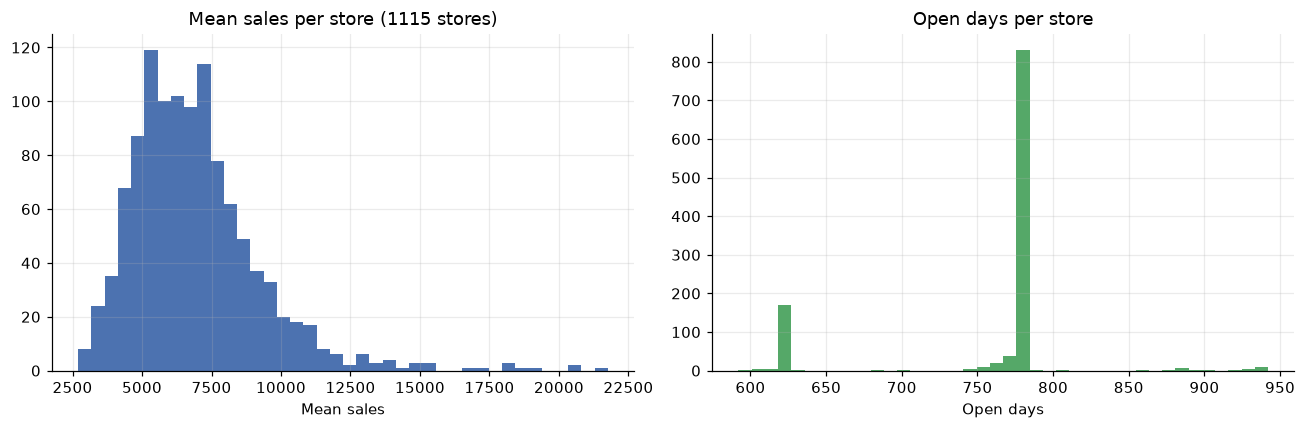

In [22]:
fig = eda.plot_store_heterogeneity(eda_df)
eda.save_fig(fig, "05_store_heterogeneity")

## 9. a composition trap (day of week)

In [23]:
eda_df.groupby("day_of_week").agg(
    n_rows=("sales", "size"), n_stores=("store", "nunique"), mean_sales=("sales", "mean")
)

,n_rows,n_stores,mean_sales
day_of_week,,,
1,137557,1115,"8,216.25"
2,143955,1115,"7,088.41"
3,141922,1115,"6,728.79"
4,134626,1115,"6,768.21"
5,138633,1115,"7,073.03"
6,144052,1115,"5,875.08"
7,3593,33,"8,224.72"


## 10.  correlations and multicollinearity

WindowsPath('C:/Users/PMYLS/Desktop/regression-intelligence-system/reports/figures/06_correlation.png')

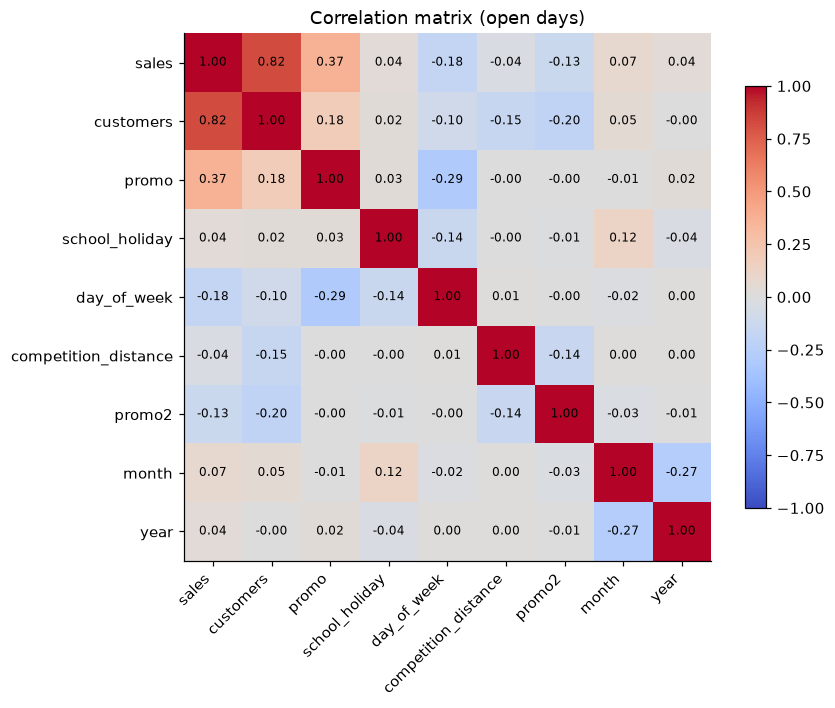

In [24]:
corr_cols = [
    "sales",
    "customers",
    "promo",
    "school_holiday",
    "day_of_week",
    "competition_distance",
    "promo2",
    "month",
    "year",
]

fig = eda.plot_correlation(eda_df, corr_cols)
eda.save_fig(fig, "06_correlation")

In [25]:
# customers is excluded: it is leakage (unknown before the day ends)
eda.compute_vif(
    eda_df, ["promo", "school_holiday", "competition_distance", "promo2", "month", "year"]
)

,feature,vif
4,month,1.09
5,year,1.08
3,promo2,1.02
2,competition_distance,1.02
1,school_holiday,1.02
0,promo,1.00


## 11.anomalies

In [26]:
print("Open days with zero sales:")
display(df[(df["open"] == 1) & (df["sales"] == 0)].head(10))

Open days with zero sales:


,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
18600,762,4,2013-01-17,0,0,1,0,0,0,d,c,"1,280.00",NaN,NaN,1,10.00,"2,013.00","Mar,Jun,Sept,Dec"
25875,232,4,2013-01-24,0,0,1,1,0,0,c,c,"13,570.00",5.00,"2,010.00",1,10.00,"2,013.00","Mar,Jun,Sept,Dec"
32672,339,3,2013-01-30,0,0,1,0,0,0,a,c,"2,280.00",NaN,NaN,1,10.00,"2,013.00","Mar,Jun,Sept,Dec"
33787,339,4,2013-01-31,0,0,1,0,0,0,a,c,"2,280.00",NaN,NaN,1,10.00,"2,013.00","Mar,Jun,Sept,Dec"
41512,259,4,2013-02-07,0,0,1,1,0,0,b,b,210.00,NaN,NaN,0,NaN,NaN,NaN
82861,353,6,2013-03-16,0,0,1,0,0,0,b,b,900.00,NaN,NaN,1,14.00,"2,013.00","Feb,May,Aug,Nov"
128056,948,4,2013-04-25,0,5,1,1,0,0,b,b,"1,430.00",NaN,NaN,0,NaN,NaN,NaN
132157,589,1,2013-04-29,0,0,1,1,0,0,a,c,360.00,NaN,NaN,1,18.00,"2,013.00","Feb,May,Aug,Nov"
140852,364,2,2013-05-07,0,0,1,0,0,0,a,c,"13,620.00",NaN,NaN,1,10.00,"2,014.00","Mar,Jun,Sept,Dec"
141967,364,3,2013-05-08,0,0,1,0,0,0,a,c,"13,620.00",NaN,NaN,1,10.00,"2,014.00","Mar,Jun,Sept,Dec"


In [27]:
print("Ten largest sales:")
display(eda_df.nlargest(10, "sales")[["store", "date", "sales", "promo", "store_type"]])

Ten largest sales:


,store,date,sales,promo,store_type
973517,909,2015-06-22,41551,0,a
883670,262,2015-04-03,38722,1,b
914890,262,2015-05-01,38484,1,b
929385,262,2015-05-14,38367,0,b
592120,57,2014-06-16,38037,1,d
389950,817,2013-12-16,38025,1,a
389394,261,2013-12-16,37646,1,d
572255,262,2014-05-29,37403,0,b
396085,262,2013-12-22,37376,0,b
770759,262,2014-12-21,37122,0,b


# Key Findings & Next Steps

### 1. Target Variable (Sales) & Business Logic

#### Closed Days: 
About 17% of the dataset consists of days when stores were closed, resulting in zero sales. We will drop these rows during data cleaning so the model focuses strictly on active sales days.

#### Distribution: 
Sales data is right-skewed. Applying a log transformation (log1p) makes the distribution much more symmetric, which will help linear                          models perform better. We’ll test training on log-transformed targets and evaluate performance back in original units.

## 2. Feature Analysis & Selection
#### Promotions: 
Promo days consistently show higher sales. We’ll keep the promo feature and test interaction terms, such as promo × day_of_week .

#### Seasonality & Calendar Effects:
Strong weekly and seasonal (especially December) patterns exist,  day_of_week should be treated as a categorical variable and one-hot encoded rather than kept as a raw number.

#### Store Variation:
Average sales vary drastically across individual stores. Store identity is critical, but any store-level aggregations (like mean sales per store) must be calculated strictly on training data to avoid data leakage .

#### Data Leakage Risk: 
customers has a strong correlation with sales, but customer counts are only known after the day ends. We must exclude this feature from model training to prevent leakage.

## 3. Data Quality & Missing Values
#### Missing Promo Information:
Missing values in promo2_since_* and promo_interval only occur when promo2 == 0. Instead of blind imputation, we will handle these with domain-aware logic.

#### Sunday Sales Anomaly: 
Raw means for Sundays look unusual because only a specific subset of stores remain open. This is a composition effect, so we shouldn't draw broad business conclusions from raw Sunday averages alone.

## 4. Modeling & Validation Strategy
#### Time Trends: 
Sales show clear overall trends from 2013 to 2015. We must use a chronological (time-based) split rather than a random split to properly evaluate model generalization (Stage 5).

#### Multicollinearity:
Low Variance Inflation Factor (VIF) scores among raw features are expected. Heavy collinearity will likely appear once we engineer calendar and store features, which is where regularized models (Ridge, Lasso, ElasticNet) will be useful.